In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import h5py
import matplotlib.pyplot as plt
import autoencoder
import config
import torch
from ipywidgets import interact
import ipywidgets as widgets



all_thbn = autoencoder.concatenate_data(f'{config.DATA_DIR}/thumbnails.h5', key='thumbnails')
train_data =autoencoder.process_thumbnails(all_thbn)

In [2]:
latent_dim = 128

data_tensor = torch.tensor(train_data, dtype=torch.float32)
device = autoencoder.get_device()

model = autoencoder.ParticleAE(latent_dim=latent_dim).to(device)
model.load_state_dict(torch.load(f"{config.DATA_DIR}/model_ld{latent_dim}.pth", map_location=device, weights_only=True))
# 3. Get the Latent Vectors
model.eval()
with torch.no_grad():
    _, latent = model(data_tensor.to(device))
    latent = latent.cpu().numpy()

Found mps


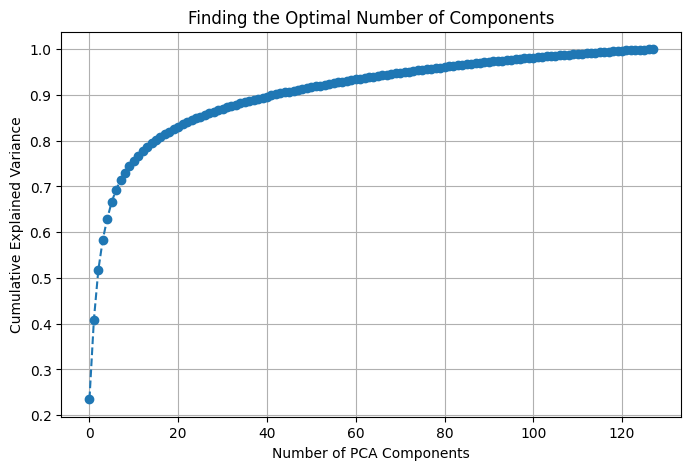

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming 'latent_features' is your array of encoded thumbnails
pca = PCA().fit(latent)

# Plot the cumulative variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Finding the Optimal Number of Components')
plt.grid(True)
plt.show()

from sklearn.cluster import KMeans

# 1. Take just the top 5 components
pca_features = pca.transform(latent)[:, :5]

# 2. Cluster into 3 groups (Focused, Unfocused, Wild Shapes)
kmeans = KMeans(n_clusters=3, random_state=42).fit(pca_features)
labels = kmeans.labels_

In [4]:
labels


array([2, 2, 0, ..., 2, 0, 0], shape=(19097,), dtype=int32)

In [5]:
# 4. Project to 2D
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(latent)

# save to h5
with h5py.File(f'{config.DATA_DIR}/pca_ld{latent_dim}.h5', 'w') as f:
    f['/coords'] = coords
    f['/latent_dim'] = latent_dim
    

In [6]:
# 5. Plot!'
def plot_thumb(i):
    fig, ax = plt.subplots(1,1, figsize=(2,2))
    ax.imshow(all_thbn[i])
    #ax[1].imshow(train_data[i,0])
    plt.show()

interact(plot_thumb, i=(0, all_thbn.shape[0]-1,1))

interactive(children=(IntSlider(value=9548, description='i', max=19096), Output()), _dom_classes=('widget-inte…

<function __main__.plot_thumb(i)>

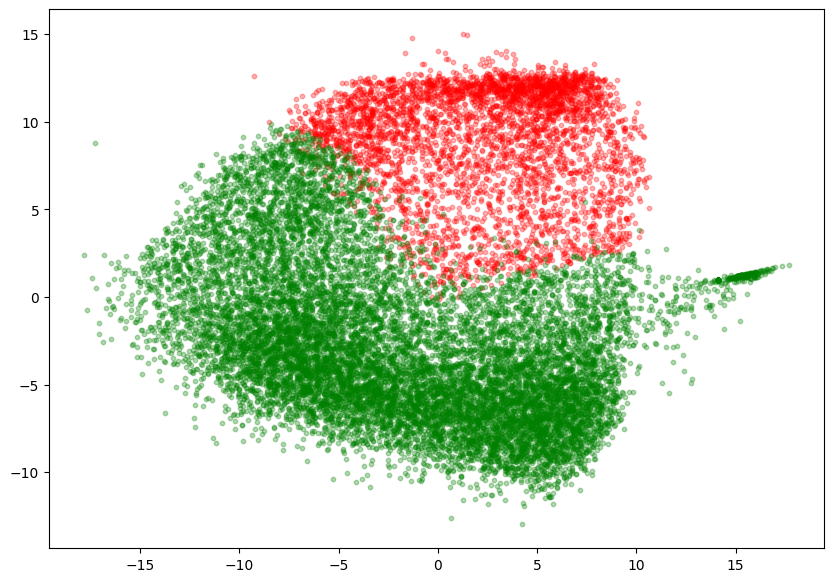

In [8]:
plt.figure(figsize=(10, 7))
# Plot rejected (Red) peaks
plt.scatter(coords[labels==0, 0], coords[labels==0, 1], 
        c='red', label='', alpha=0.3, s=10)
plt.scatter(coords[labels!=0, 0], coords[labels!=0, 1], 
        c='green', label='', alpha=0.3, s=10)

plt.show()